In [1]:
import time
import math
import matplotlib.pyplot as plt
from dds import DDS

In [2]:
class PID_Controller:
    def __init__(self, kp, ki, kd):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        
        self.prev_error = 0.0
        self.integral = 0.0

    def evaluate(self, error, delta_t):
        if delta_t <= 0:
            return 0.0
        
        p_out = self.kp * error
        
        self.integral += error * delta_t
        i_out = self.ki * self.integral

        derivative = (error - self.prev_error) / delta_t
        d_out = self.kd * derivative

        self.prev_error = error

        return p_out + i_out + d_out

In [ ]:
dds = DDS()
dds.start('127.0.0.1', 4444)
dds.subscribe(['tick', 'X', 'Z', 'Yaw', 'Speed', 'X_dest', 'Z_dest', 'Indice'])


current_wp_index = 0
acceptance_radius = 1.5


target_speed = 3
max_torque = 150

speed_pid = PID_Controller(35.0, 120.0, 0.5)
steering_pid = PID_Controller(kp=1.3, ki=0.0, kd=0.0)

max_steering = 35


d_x = []
d_z = []   
d_time = []
d_target_speed = []
d_current_speed = []
d_angle_error = []
d_steering = []

print("Starting robot conrtrol...")
start_time = time.time()

try:
    while True:
        delta_t = dds.wait('tick')
        if delta_t is None:
            continue
            
        t_elapsed = time.time() - start_time
        
        

        x = dds.read('X')
        z = dds.read('Z')
        yaw = dds.read('Yaw') 
        current_speed = dds.read('Speed')
        target_x = dds.read('X_dest')
        target_z = dds.read('Z_dest')
        index = dds.read('Indice')

        if None in (x, z, yaw, current_speed):
            print('error')
            continue

        if target_x == -999:
            print('Path finished! Terminating.')
            dds.publish('Torque', 0, DDS.DDS_TYPE_FLOAT)
            dds.publish('Theta', 0, DDS.DDS_TYPE_FLOAT)
            break

        yaw_deg = math.degrees(yaw)
        dist_to_target = math.hypot(target_x - x, target_z - z)
        target_angle = math.atan2(target_x - x, target_z - z)
        target_angle = math.degrees(target_angle)
        angle_error = target_angle - yaw_deg
        

        if dist_to_target < acceptance_radius:
            print(f'Waypoint {index + 1} reached! ({target_x}, {target_z})')
            index += 1
            
            dds.publish('Index', index, DDS.DDS_TYPE_INT)
            
        angle_error = (angle_error + 180) % 360 - 180
        raw_steering = steering_pid.evaluate(angle_error, delta_t)
        target_steering = max(-max_steering, min(max_steering, raw_steering))

        speed_error = target_speed - current_speed
        raw_torque = speed_pid.evaluate(speed_error, delta_t)
        torque = max(-max_torque, min(max_torque, raw_torque))



        # Invio dati a Godot
        dds.publish('Torque', torque, DDS.DDS_TYPE_FLOAT)
        dds.publish('Theta', target_steering, DDS.DDS_TYPE_FLOAT)

        d_time.append(t_elapsed)
        d_x.append(x)
        d_z.append(z)
        d_target_speed.append(target_speed)
        d_current_speed.append(current_speed)
        d_angle_error.append(angle_error)
        d_steering.append(target_steering)

except KeyboardInterrupt:
    print('interrotto')

Starting robot conrtrol...
Waypoint 1 reached! (0.0, 0.0)
Waypoint 1 reached! (0.0, 0.0)
Waypoint 2 reached! (0.0, 10.0)
Waypoint 2 reached! (0.0, 10.0)
Waypoint 3 reached! (0.0, 20.0)
Waypoint 3 reached! (0.0, 20.0)
Waypoint 4 reached! (0.0, 30.0)
Waypoint 4 reached! (0.0, 30.0)
Waypoint 5 reached! (10.0, 30.0)
Waypoint 5 reached! (10.0, 30.0)
Waypoint 6 reached! (10.0, 20.0)
Waypoint 6 reached! (10.0, 20.0)
Waypoint 7 reached! (10.0, 10.0)
Waypoint 7 reached! (10.0, 10.0)
Waypoint 8 reached! (20.0, 10.0)
Waypoint 8 reached! (20.0, 10.0)
Waypoint 9 reached! (20.0, 0.0)
Waypoint 9 reached! (20.0, 0.0)
Waypoint 10 reached! (30.0, 0.0)
Waypoint 10 reached! (30.0, 0.0)
Waypoint 11 reached! (40.0, 0.0)
Waypoint 11 reached! (40.0, 0.0)
Waypoint 12 reached! (40.0, 10.0)
Waypoint 12 reached! (40.0, 10.0)
Waypoint 13 reached! (40.0, 20.0)
Waypoint 13 reached! (40.0, 20.0)
Waypoint 14 reached! (30.0, 20.0)
Waypoint 14 reached! (30.0, 20.0)
Waypoint 15 reached! (20.0, 20.0)
Waypoint 15 reached! 

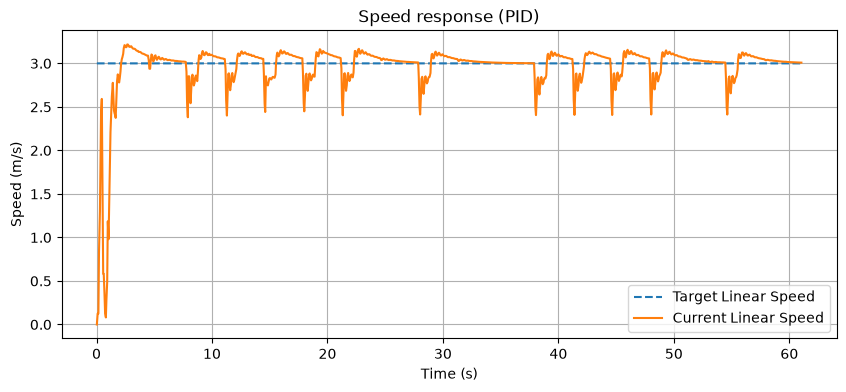

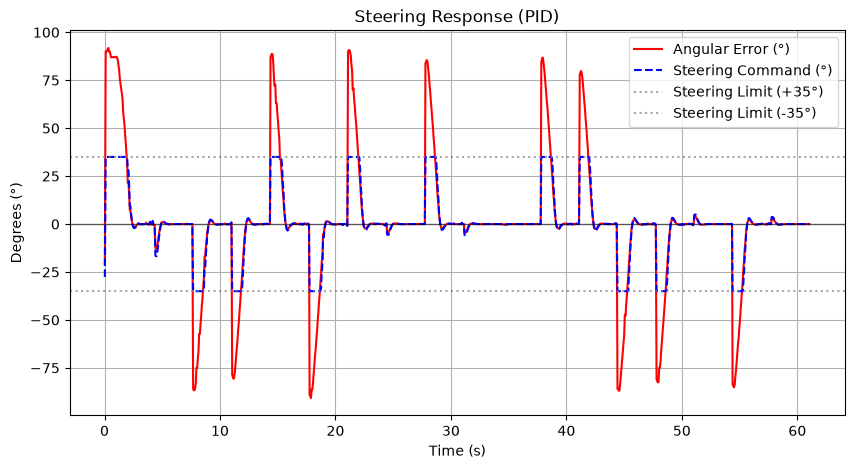

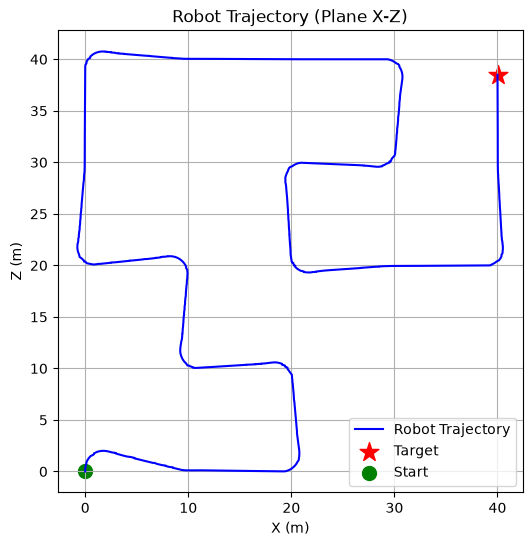

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(d_time, d_target_speed, label="Target Linear Speed", linestyle='--')
plt.plot(d_time, d_current_speed, label="Current Linear Speed")
plt.title("Speed response (PID)")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(d_time, d_angle_error, label="Angular Error (°)", color='red')
plt.plot(d_time, d_steering, label="Steering Command (°)", color='blue', linestyle='--')
plt.axhline(y=35, color='gray', linestyle=':', alpha=0.7, label="Steering Limit (+35°)")
plt.axhline(y=-35, color='gray', linestyle=':', alpha=0.7, label="Steering Limit (-35°)")
plt.axhline(y=0, color='black', linewidth=1, alpha=0.5) 

plt.title("Steering Response (PID)")
plt.xlabel("Time (s)")
plt.ylabel("Degrees (°)")
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(6, 6))
plt.plot(d_x, d_z, label="Robot Trajectory", color='blue')
# Usa l'ultima posizione reale registrata nelle liste d_x e d_z
plt.scatter([d_x[-1]], [d_z[-1]], color='red', marker='*', s=200, label="Target")
plt.scatter([d_x[0]], [d_z[0]], color='green', marker='o', s=100, label="Start")
plt.title("Robot Trajectory (Plane X-Z)")
plt.xlabel("X (m)")
plt.ylabel("Z (m)")
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()